# ftir_51 — the priority figure export: every requested graph, with its settings line

## tl;dr

This notebook exports the ten items on the "graphs to send me" list as PNGs into
`output/plots/ftir51/`, each with a one-line settings caption (variant, k, MAC, lot,
protocol, evaluation set) collected in `MANIFEST.md` and zipped for sending. Nothing
new is fitted here: every regression number is read from the running Calibration
Iteration Explorer (`calibration_explorer/`, port 5058), which serves the one shared
implementation the committed notebooks validate against (ftir_21 modes, Deming from
`pls_transfer.py`). Unless a panel says otherwise the conventions are the locked ones:
**Option A** protocol (site-grouped 5-fold CV, first-major-minimum k), **Deming**
λ*=2.96 at **MAC 10**, regression on the **fixed 190-filter** deployed cohort,
training lot = all, evaluation target = Addis (ETAD) screened baseline.

What the export shows, in the list's order:

1. **Before/after crossplots (four panels).** Network-wide raw → network-wide
   corrected, and analog-selected raw → analog-selected on corrected spectra: the
   intercept story in one image.
2. **Component sweep.** Intercept vs k with held-out TOR R² on the second axis, for
   seven variants, straight from `/api/sweep`.
3. **Seasonal robustness.** Monthly medians and season boxplots of predicted Addis EC
   under four calibrations: Kiremt-high / Dry-low every time.
4. **Analog rank-score distributions**, raw vs corrected selection space, with the
   top-500 cutoff and the distribution peak marked.
5. **CV comparison table**: Options A, B (calibration app) and B2, side by side.
6. **Lot 248 vs 251** crossplots (lowest-OC/EC 800 trained on each lot separately)
   with the pool counts and the hypothesis.
7. **Plausibility markers per variant**: negatives, days above 8 µg/m³, median,
   season medians, trend.
8. **Explorer screenshot** with the configuration dropdown and the k sweep visible
   (headless Chromium via Playwright, falling back to the group-talk screenshot).
9. **Backup images**: the PMF-class crossplot and the implied-MAC figures that exist
   as files, plus the aethalometer-vs-FTIR figures extracted from the notebooks that
   embed them (no standalone aethalometer-BC-vs-FTIR-EC or seasonal-MAC image
   exists in the repo).
10. **Permutation CSV** from the explorer's batch cache (slope, intercept, R², k,
   rule, n per run).
11. **OC/EC and OC/fAbs by site**, SPARTAN (FTIR) placed in the IMPROVE (thermal-optical)
   ranking, one figure each with the legend outside.

## Context & Methods

The Aug-18 and Aug-27 decks carried most of these figures, but their builders were
session-local, so the figures could not be regenerated on demand. This notebook
replaces that with one executed record: each cell calls the explorer API with an
explicit configuration, draws the figure from the returned predictions and metrics,
and appends the settings line to the manifest. Re-running it against a live explorer
reproduces the whole packet.

In [1]:
%matplotlib inline
import io
import json
import sys
import os
import shutil
import time
import urllib.request
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown

PORT = int(os.environ.get("EXPLORER_PORT", 5058))
BASE = f"http://127.0.0.1:{PORT}"
REPO = Path("..") / ".."
PLOTS = Path("output/plots/ftir51")
TABLES = Path("output/tables/ftir51")
PLOTS.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

INK, GREY, BLUE, PURPLE, ACCENT = "#1F1F1F", "#8F8C84", "#2C6E9E", "#7A4FA3", "#B23327"
AMBER, GREEN = "#C8862B", "#4E8A5B"
SEASON_COLOUR = {"Dry": AMBER, "Belg": GREEN, "Kiremt": BLUE}
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#E8E6E1", "grid.linewidth": 0.6,
                     "axes.axisbelow": True, "figure.facecolor": "white",
                     "savefig.dpi": 200, "savefig.facecolor": "white"})


def api_get(path):
    return json.load(urllib.request.urlopen(f"{BASE}{path}", timeout=60))


def api_post(path, body, timeout=1800):
    req = urllib.request.Request(f"{BASE}{path}", json.dumps(body).encode(),
                                 {"Content-Type": "application/json"})
    out = json.load(urllib.request.urlopen(req, timeout=timeout))
    if isinstance(out, dict) and out.get("error"):
        raise RuntimeError(f"{path}: {out['error']}")
    return out


status = api_get("/api/status")
assert status["ready"], status["message"]
print("explorer ready · commit", status["provenance"]["git_commit"],
      "(dirty)" if status["provenance"]["git_dirty"] else "",
      "· cache schema", status["provenance"]["cache_schema"])
for c in status["checks"]:
    print(("  ok " if c["ok"] else "  !! ") + c["name"] + ": " + c["detail"])

explorer ready · commit f48fda4d41fb68d0c9fdb4fa1f918c179d360b49 (dirty) · cache schema 2026-08-24-v3-q-residual
  ok pool spectra loaded via polars: polars is the fast path when installed; CALIB_EXPLORER_CSV=pandas forces the pandas read
  ok PMF source groups attached to Addis: 102/239 evaluation filters have a PMF day (exact date match)
  ok Ethiopia-shaped top-300 == locked selection: 300/300 overlap
  ok analog top-500 == locked analog cohort: 500/500 overlap
  ok lowest-OC/EC top-800 == committed ftir_11 cohort: 800/800 overlap


### The variants

Seven named configurations cover everything the list asks for. Each is one explorer
run; `k` is the Option-A rule choice unless pinned (the search winner is pinned at
k=9, the value the dense sweep selected).

In [2]:
VARIANTS = {
    "network_raw": dict(label="Entire IMPROVE network, raw spectra",
                        cohort="pool", spectra="raw"),
    "network_corr": dict(label="Entire IMPROVE network, baseline-corrected (AIRSpec)",
                         cohort="pool", spectra="airspec"),
    "analogs_raw": dict(label="Spectral analogs 500, selected on raw, calibrated on raw",
                        cohort="analogs", cutoff=500, selection_space="raw", spectra="raw"),
    "analogs_selcorr": dict(label="Spectral analogs 500, selected on baseline-corrected, "
                                  "calibrated on raw",
                            cohort="analogs", cutoff=500, selection_space="airspec",
                            spectra="raw"),
    "ocec800_raw": dict(label="Lowest-OC/EC 800, raw spectra",
                        cohort="ocec", cutoff=800, spectra="raw"),
    "ocec800_corr": dict(label="Lowest-OC/EC 800, baseline-corrected (AIRSpec)",
                         cohort="ocec", cutoff=800, spectra="airspec"),
    "ocec450_corr_k9": dict(label="Lowest-OC/EC 450, baseline-corrected, k=9 (search winner)",
                            cohort="ocec", cutoff=450, spectra="airspec", k=9),
}
COLOUR = {"network_raw": GREY, "network_corr": INK, "analogs_raw": "#B48CD1",
          "analogs_selcorr": PURPLE, "ocec800_raw": "#E0A458", "ocec800_corr": ACCENT,
          "ocec450_corr_k9": GREEN}
SPECTRA_LABEL = {"raw": "raw", "airspec": "baseline-corrected (AIRSpec)"}
MODE_LABEL = {"site_heldout": "Option A: site-grouped 5-fold CV, first major minimum",
              "app": "Option B: interleaved 10-fold CV, within 5% (calibration app)",
              "app_fmm": "Option B2: interleaved 10-fold CV, first major minimum"}
DEFAULTS = dict(mode="site_heldout", target="addis", lot="all", eval_lot="all")


def cfg_of(v, **override):
    body = {k: val for k, val in v.items() if k != "label"}
    body = {**DEFAULTS, **body, **override}
    return body


_RUNS = {}


def run(body):
    key = json.dumps(body, sort_keys=True)
    if key not in _RUNS:
        t0 = time.time()
        _RUNS[key] = api_post("/api/run", body)
        print(f"  run {body.get('cohort')}/{body.get('cutoff') or 'all'} "
              f"sel={body.get('selection_space', 'raw')} cal={body['spectra']} "
              f"mode={body['mode']} lot={body['lot']} k={body.get('k') or 'rule'}: "
              f"{time.time() - t0:.1f}s")
    return _RUNS[key]


def pick(d, eval_set="fixed", mac=10):
    rows = [m for m in d["metrics"] if m["MAC"] == mac and m["evaluation_set"] == eval_set]
    if not rows:
        rows = [m for m in d["metrics"] if m["MAC"] == mac]
    return rows[0]


def settings_line(body, d, eval_set="fixed", extra=""):
    m = pick(d, eval_set)
    sel = body.get("selection_space", "raw") if body["cohort"] in ("analogs", "eth_shaped") else None
    parts = [f"{d['cohort_label']} (n={d['n_cohort']})"]
    if sel:
        parts.append(f"selected on {SPECTRA_LABEL[sel]}")
    parts += [f"calibrated on {SPECTRA_LABEL[body['spectra']]}",
              MODE_LABEL[body["mode"]],
              f"k={d['k']}" + ("" if d["k"] == d["auto_k"] else f" (pinned; rule would give {d['auto_k']})"),
              "MAC 10", f"training lot {body['lot']}",
              f"eval Addis {'fixed 190' if eval_set == 'fixed' else 'all pairs'} (n={m['n']})",
              f"Deming {m['deming_slope']:.2f}x{m['deming_intercept']:+.2f}",
              f"OLS {m['ols_slope']:.2f}x{m['ols_intercept']:+.2f}", f"R² {m['R2']:.2f}"]
    if d.get("heldout"):
        parts.append(f"held-out TOR R² {d['heldout']['R2']:.2f}")
    if extra:
        parts.append(extra)
    return " · ".join(parts)


MANIFEST = []


def save(fig, name, settings):
    path = PLOTS / name
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)
    im = Image.open(path)
    if im.mode != "RGB":          # PowerPoint chokes on RGBA
        im.convert("RGB").save(path)
    MANIFEST.append((name, settings))
    print(f"saved {path}")


def crossplot(ax, d, colour, title, eval_set="fixed", ho=True):
    m = pick(d, eval_set)
    ref = np.array(d["eval"]["ref"], float) / 10.0            # Fabs/MAC at MAC 10
    pred = np.array(d["eval"]["pred"], float)
    fixed = np.array(d["eval"]["fixed"], bool)
    sel = fixed if (eval_set == "fixed" and fixed.any()) else np.isfinite(pred)
    x, y = ref[sel], pred[sel]
    lim = max(np.nanmax(x), np.nanmax(y), 1.0) * 1.06
    ax.plot([0, lim], [0, lim], ls=":", color=GREY, lw=1.1)
    ax.axhline(0, color="#555", lw=0.8)
    ax.scatter(x, y, s=14, color=colour, alpha=0.6, edgecolor="none")
    xs = np.linspace(0, lim, 20)
    ax.plot(xs, m["deming_slope"] * xs + m["deming_intercept"], color=INK, lw=1.8)
    ax.set_xlim(0, lim)
    ax.set_ylim(min(0.0, m["deming_intercept"]) - 0.4, lim)
    ax.set_xlabel("HIPS EC-equivalent, Fabs/10 (µg/m³)")
    ax.set_ylabel("FTIR-predicted EC (µg/m³)")
    txt = (f"{title}\nDeming {m['deming_slope']:.2f}x{m['deming_intercept']:+.2f}"
           f"\nOLS {m['ols_slope']:.2f}x{m['ols_intercept']:+.2f}"
           f"\nR² {m['R2']:.2f} · n = {m['n']} · k = {d['k']}")
    if ho and d.get("heldout"):
        txt += f"\nheld-out TOR R² {d['heldout']['R2']:.2f}"
    ax.text(0.03, 0.97, txt, transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(fc="white", ec="#DDDAD2", alpha=0.92))
    return m


runs = {name: run(cfg_of(v)) for name, v in VARIANTS.items()}
summary = pd.DataFrame([{"variant": name, "cohort n": d["n_cohort"], "k": d["k"],
                         "rule k": d["auto_k"],
                         **{k2: pick(d)[k2] for k2 in ("deming_slope", "deming_intercept",
                                                        "ols_slope", "ols_intercept", "R2")},
                         "held-out TOR R²": (d["heldout"] or {}).get("R2")}
                        for name, d in runs.items()]).set_index("variant")
summary.to_csv(TABLES / "variant_summary.csv")
display(summary.round(3))

  run pool/all sel=raw cal=raw mode=site_heldout lot=all k=rule: 0.1s
  run pool/all sel=raw cal=airspec mode=site_heldout lot=all k=rule: 0.1s


  run analogs/500 sel=raw cal=raw mode=site_heldout lot=all k=rule: 0.0s
  run analogs/500 sel=airspec cal=raw mode=site_heldout lot=all k=rule: 0.0s
  run ocec/800 sel=raw cal=raw mode=site_heldout lot=all k=rule: 0.0s
  run ocec/800 sel=raw cal=airspec mode=site_heldout lot=all k=rule: 0.0s


  run ocec/450 sel=raw cal=airspec mode=site_heldout lot=all k=9: 0.0s


,cohort n,k,rule k,deming_slope,deming_intercept,ols_slope,ols_intercept,R2,held-out TOR R²
variant,,,,,,,,,
network_raw,13010,15,15,1.937,-4.820,1.655,-3.438,0.753,0.695
network_corr,13010,7,7,0.474,-0.784,0.457,-0.700,0.647,0.660
analogs_raw,500,4,4,3.090,-9.320,2.481,-6.347,0.746,0.367
analogs_selcorr,500,15,15,1.943,-4.683,1.634,-3.170,0.732,0.704
ocec800_raw,800,6,6,1.814,-4.338,1.585,-3.222,0.774,0.911
ocec800_corr,800,5,5,0.954,-2.089,0.857,-1.615,0.657,0.904
ocec450_corr_k9,450,9,5,0.998,-1.710,0.912,-1.289,0.714,0.918


## 1. Addis crossplots, before and after (four panels)

(a) network-wide calibration on raw spectra, (b) the same on baseline-corrected
spectra, (c) spectral-analog selection on raw spectra, (d) analog selection with the
baseline applied before selection (calibration still on raw, per Satoshi). Each panel
states Deming and OLS fits, R², n and k; the fits are on the fixed 190 deployed filters.

In [3]:
FOUR = [("network_raw", "(a) IMPROVE-wide, raw spectra", GREY),
        ("network_corr", "(b) IMPROVE-wide, baseline-corrected", BLUE),
        ("analogs_raw", "(c) spectral analogs, selected on raw", "#B48CD1"),
        ("analogs_selcorr", "(d) analogs selected on baseline-corrected", PURPLE)]
fig, axes = plt.subplots(2, 2, figsize=(11.5, 10.5))
lines = []
for ax, (name, title, colour) in zip(axes.ravel(), FOUR):
    m = crossplot(ax, runs[name], colour, title)
    lines.append(f"{title}: {settings_line(cfg_of(VARIANTS[name]), runs[name])}")
fig.tight_layout()
save(fig, "01_addis_crossplots_before_after.png", "\n    ".join(lines))
display(Markdown("\n".join(f"- {l}" for l in lines)))

saved output/plots/ftir51/01_addis_crossplots_before_after.png


- (a) IMPROVE-wide, raw spectra: Entire IMPROVE network (no selection) (n=13010) · calibrated on raw · Option A: site-grouped 5-fold CV, first major minimum · k=15 · MAC 10 · training lot all · eval Addis fixed 190 (n=190) · Deming 1.94x-4.82 · OLS 1.65x-3.44 · R² 0.75 · held-out TOR R² 0.70
- (b) IMPROVE-wide, baseline-corrected: Entire IMPROVE network (no selection) (n=13010) · calibrated on baseline-corrected (AIRSpec) · Option A: site-grouped 5-fold CV, first major minimum · k=7 · MAC 10 · training lot all · eval Addis fixed 190 (n=190) · Deming 0.47x-0.78 · OLS 0.46x-0.70 · R² 0.65 · held-out TOR R² 0.66
- (c) spectral analogs, selected on raw: Spectral analogs (top 500) (n=500) · selected on raw · calibrated on raw · Option A: site-grouped 5-fold CV, first major minimum · k=4 · MAC 10 · training lot all · eval Addis fixed 190 (n=190) · Deming 3.09x-9.32 · OLS 2.48x-6.35 · R² 0.75 · held-out TOR R² 0.37
- (d) analogs selected on baseline-corrected: Spectral analogs (top 500, corrected-space selection) (n=500) · selected on baseline-corrected (AIRSpec) · calibrated on raw · Option A: site-grouped 5-fold CV, first major minimum · k=15 · MAC 10 · training lot all · eval Addis fixed 190 (n=190) · Deming 1.94x-4.68 · OLS 1.63x-3.17 · R² 0.73 · held-out TOR R² 0.70

## 2. Component sweep

Intercept (Deming, MAC 10, fixed 190) against the number of PLS components, with the
held-out IMPROVE TOR R² on the second axis, for all seven variants. Hollow markers are
each variant's rule-chosen (or pinned) k. Raw-spectra calibrations dashed,
baseline-corrected calibrations solid.

In [4]:
KS = [3, 4, 6, 8, 10, 12, 15, 18, 21, 24, 30]
sweep_rows = []
for name, v in VARIANTS.items():
    body = {k: val for k, val in cfg_of(v).items() if k != "k"}
    t0 = time.time()
    out = api_post("/api/sweep", {**body, "ks": KS})
    print(f"  sweep {name}: {len(out['rows'])} k values in {time.time() - t0:.0f}s")
    for r in out["rows"]:
        sweep_rows.append({"variant": name, **{k2: r[k2] for k2 in
                           ("k", "auto_k", "rmsecv", "ols_intercept", "ols_slope",
                            "deming_intercept", "deming_slope", "R2", "heldout_R2",
                            "negative_pct", "above_8_pct", "prediction_median")}})
sweep = pd.DataFrame(sweep_rows)
sweep.to_csv(TABLES / "component_sweep.csv", index=False)

SWEEP_NOTE = (f"k in {KS}; all seven variants under {MODE_LABEL['site_heldout']}; intercept = Deming "
              "MAC 10 on fixed 190; held-out R² = site-disjoint IMPROVE TOR test; training lot all; "
              "hollow marker = rule-chosen (or pinned) k; raw calibrations dashed, baseline-corrected "
              "solid. Rows in output/tables/ftir51/component_sweep.csv")


def sweep_panel(field, ylabel, fname, ylim=None, zero_line=False):
    """One sweep quantity per figure, legend outside to the right."""
    fig, ax = plt.subplots(figsize=(11.5, 5.2))
    for name, v in VARIANTS.items():
        s = sweep[sweep.variant == name]
        ls = "-" if v["spectra"] == "airspec" else "--"
        ax.plot(s.k, s[field], ls=ls, marker="o", ms=4, color=COLOUR[name], label=v["label"])
        d = runs[name]
        y_rule = pick(d)["deming_intercept"] if field == "deming_intercept" else d["heldout"]["R2"]
        ax.plot([d["k"]], [y_rule], marker="o", ms=11, mfc="white", mec=COLOUR[name], mew=1.8,
                ls="none")
    if zero_line:
        ax.axhline(0, color="#555", lw=0.8)
    if ylim:
        ax.set_ylim(*ylim)
    ax.set_xlabel("PLS components (k)")
    ax.set_ylabel(ylabel)
    ax.legend(frameon=False, fontsize=8.5, loc="upper left", bbox_to_anchor=(1.01, 1.0),
              title="hollow marker = rule-chosen k", title_fontsize=8)
    fig.tight_layout()
    save(fig, fname, SWEEP_NOTE)


sweep_panel("deming_intercept", "Addis intercept, Deming MAC 10, fixed 190 (µg/m³)",
            "02a_component_sweep_intercept.png", zero_line=True)
sweep_panel("heldout_R2", "held-out IMPROVE TOR R² (site-held-out)",
            "02b_component_sweep_heldout_r2.png", ylim=(0, 1))
display(sweep.pivot(index="k", columns="variant", values="deming_intercept").round(2))

  sweep network_raw: 11 k values in 1s


  sweep network_corr: 11 k values in 1s


  sweep analogs_raw: 11 k values in 0s


  sweep analogs_selcorr: 11 k values in 0s


  sweep ocec800_raw: 11 k values in 0s
  sweep ocec800_corr: 11 k values in 0s


  sweep ocec450_corr_k9: 11 k values in 0s


saved output/plots/ftir51/02a_component_sweep_intercept.png


saved output/plots/ftir51/02b_component_sweep_heldout_r2.png


variant,analogs_raw,analogs_selcorr,network_corr,network_raw,ocec450_corr_k9,ocec800_corr,ocec800_raw
k,,,,,,,
3,-8.71,-1.30,-0.40,-1.06,-2.30,-1.04,-7.31
4,-9.32,-4.18,-0.66,-0.91,-1.85,-1.91,-6.34
6,-9.21,-2.69,-0.86,-1.47,-1.71,-1.86,-4.34
8,-10.49,-2.34,-1.16,-2.90,-1.65,-1.94,-4.69
10,-10.03,-4.36,-1.26,-3.77,-2.23,-2.05,-5.34
12,-10.64,-5.00,-1.48,-4.04,-3.56,-2.18,-6.01
15,-10.91,-4.68,-1.64,-4.82,-3.18,-1.93,-7.06
18,-10.73,-4.29,-1.65,-5.24,-2.54,-2.08,-7.14
21,-10.71,-4.37,-1.87,-5.63,-1.80,-1.65,-6.87


## 3. Seasonal robustness

Predicted Addis EC for all dated evaluation filters (all lots) under four calibrations
that span the intercept range: monthly medians over the record, and the season
distributions. The shape (Kiremt high, Dry low) survives every calibration; only the
level moves.

In [5]:
SEASONAL = ["network_raw", "analogs_selcorr", "ocec800_raw", "ocec800_corr"]
frames = []
for name in SEASONAL:
    d = runs[name]
    frames.append(pd.DataFrame({
        "variant": name, "date": pd.to_datetime(d["eval"]["date"], errors="coerce"),
        "pred": np.array(d["eval"]["pred"], float),
        "season": [g.split(" ")[0] for g in d["eval"]["group"]]}))
ts = pd.concat(frames, ignore_index=True).dropna(subset=["date"])
ts["month"] = ts["date"].dt.to_period("M").dt.to_timestamp()
monthly = ts.groupby(["variant", "month"])["pred"].median().reset_index()
seas = (ts.groupby(["variant", "season"])["pred"].median().unstack()
        .reindex(SEASONAL)[["Dry", "Belg", "Kiremt"]])
seas["Kiremt/Dry"] = seas["Kiremt"] / seas["Dry"]
seas.to_csv(TABLES / "seasonal_medians.csv")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), gridspec_kw={"height_ratios": [1.15, 1]})
for name in SEASONAL:
    m = monthly[monthly.variant == name]
    ax1.plot(m.month, m.pred, marker="o", ms=4, lw=1.6, color=COLOUR[name],
             label=f"{VARIANTS[name]['label']} (k={runs[name]['k']})")
ax1.axhline(0, color="#555", lw=0.8)
ax1.set_ylabel("monthly median predicted EC (µg/m³)")
ax1.legend(frameon=False, fontsize=8.5, loc="upper left")
ax1.set_title("Addis ETAD, all dated evaluation filters · Option A · MAC 10 · lot all", fontsize=10,
              color=GREY, loc="left")
seasons = ["Dry", "Belg", "Kiremt"]
width = 0.18
for i, name in enumerate(SEASONAL):
    data = [ts[(ts.variant == name) & (ts.season == s)]["pred"].to_numpy() for s in seasons]
    pos = np.arange(len(seasons)) + (i - 1.5) * width
    bp = ax2.boxplot(data, positions=pos, widths=width * 0.85, patch_artist=True,
                     showfliers=False, medianprops=dict(color=INK, lw=1.4))
    for patch in bp["boxes"]:
        patch.set(facecolor=COLOUR[name], alpha=0.55, edgecolor=COLOUR[name])
ax2.axhline(0, color="#555", lw=0.8)
ax2.set_xticks(np.arange(len(seasons)))
ax2.set_xticklabels([f"{s} (n={int((ts[ts.variant == SEASONAL[0]].season == s).sum())})"
                     for s in seasons])
ax2.set_ylabel("predicted EC (µg/m³)")
for i, name in enumerate(SEASONAL):
    ax2.text(0.99, 0.97 - 0.06 * i,
             f"{name}: Kiremt/Dry median = {seas.loc[name, 'Kiremt/Dry']:.2f}",
             transform=ax2.transAxes, ha="right", va="top", fontsize=8.5, color=COLOUR[name])
fig.tight_layout()
save(fig, "03_seasonal_robustness.png",
     "Four calibrations, all dated Addis evaluation filters (all lots), " +
     MODE_LABEL["site_heldout"] + ", MAC 10 · " +
     " | ".join(f"{n}: k={runs[n]['k']}, Kiremt/Dry={seas.loc[n, 'Kiremt/Dry']:.2f}"
                for n in SEASONAL))
display(seas.round(2))

saved output/plots/ftir51/03_seasonal_robustness.png


season,Dry,Belg,Kiremt,Kiremt/Dry
variant,,,,
network_raw,2.94,4.13,6.40,2.18
analogs_selcorr,3.06,4.44,6.58,2.15
ocec800_raw,2.99,4.06,6.06,2.03
ocec800_corr,1.67,2.39,3.62,2.17


## 4. Analog selection distributions

The rank score used to pick the spectral-analog cohort, over the whole IMPROVE pool,
in raw and in baseline-corrected selection space. The top-500 cutoff and the
distribution peak are marked: the cut is a fixed rank on a continuous score, not a
hand-picked set.

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(9, 8.5), sharex=False)
rank_lines = []
for ax, space in zip(axes, ["raw", "airspec"]):
    r = api_post("/api/ranking", {"cohort": "analogs", "selection_space": space, "cutoff": 500})
    centers, counts = np.array(r["hist"]["centers"]), np.array(r["hist"]["counts"])
    # the last bin collects everything clipped at p99, so it cannot be "the peak"
    peak = centers[int(np.argmax(counts[:-1]))]
    ax.bar(centers, counts, width=np.diff(centers).mean(), color=PURPLE if space == "airspec"
           else "#B48CD1", edgecolor="none")
    ax.axvline(r["cutoff_metric"], color=ACCENT, ls="--", lw=1.6)
    ax.text(r["cutoff_metric"], counts.max() * 0.97, f"  top-500 cut at {r['cutoff_metric']:.3f}",
            color=ACCENT, va="top", fontsize=9)
    ax.axvline(peak, color=INK, ls=":", lw=1.2)
    ax.text(peak, counts.max() * 0.80, f"  mode at {peak:.3f}", color=INK, va="top", fontsize=9)
    ax.set_ylabel("filters")
    ax.set_xlabel(f"{r['label']}  [selection space: {SPECTRA_LABEL[space]}]")
    ax.set_title(f"the whole {r['n_total']:,}-spectrum IMPROVE pool, ranked in "
                 f"{SPECTRA_LABEL[space]} space", fontsize=10, color=GREY, loc="left")
    rank_lines.append(f"{space}: n_total={r['n_total']}, cutoff metric={r['cutoff_metric']:.4f}, "
                      f"peak={peak:.4f}, histogram clipped at p99={r['hist']['clipped_at_p99']:.3f}")
fig.tight_layout()
save(fig, "04_analog_rank_distributions.png",
     "Spectral-analog rank score (mean percentile of nearest-Addis score-space D² and "
     "VIP-weighted RMSE) over the whole pool; cutoff = top 500 · " + " | ".join(rank_lines))

saved output/plots/ftir51/04_analog_rank_distributions.png


## 5. CV comparison: Options A, B and B2

The same cohorts under the three component-selection protocols. Held-out TOR R² exists
only under Option A (the interleaved protocols fit on every cohort filter and keep no
site-disjoint test).

In [7]:
CV_VARIANTS = ["network_raw", "ocec800_raw", "ocec800_corr", "analogs_selcorr"]
cv_rows = []
for name in CV_VARIANTS:
    for mode in ("site_heldout", "app", "app_fmm"):
        d = run(cfg_of(VARIANTS[name], mode=mode))
        m = pick(d)
        cv_rows.append({"variant": name, "protocol": MODE_LABEL[mode].split(":")[0],
                        "k": d["k"], "Deming slope": m["deming_slope"],
                        "Deming int.": m["deming_intercept"], "OLS slope": m["ols_slope"],
                        "OLS int.": m["ols_intercept"], "R²": m["R2"],
                        "held-out R²": (d["heldout"] or {}).get("R2")})
cv = pd.DataFrame(cv_rows)
cv.to_csv(TABLES / "cv_protocol_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(13, 0.42 * len(cv) + 1.6))
ax.axis("off")
cell_text = [[str(r["variant"]), r["protocol"], str(r["k"]),
              f"{r['Deming slope']:.2f}", f"{r['Deming int.']:+.2f}",
              f"{r['OLS slope']:.2f}", f"{r['OLS int.']:+.2f}", f"{r['R²']:.2f}",
              "" if pd.isna(r["held-out R²"]) else f"{r['held-out R²']:.2f}"]
             for _, r in cv.iterrows()]
tbl = ax.table(cellText=cell_text, colLabels=list(cv.columns), loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.auto_set_column_width(list(range(len(cv.columns))))
tbl.scale(1.15, 1.35)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("#DDDAD2")
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#F2F0EB")
ax.set_title("Deming and OLS at MAC 10 on the fixed 190 Addis filters · training lot all · "
             "A = site-grouped 5-fold, first major minimum; B = interleaved 10-fold, within 5%; "
             "B2 = interleaved 10-fold, first major minimum",
             fontsize=9, color=GREY, loc="left")
save(fig, "05_cv_protocol_comparison.png",
     "Same cohort under three protocols; A = site-grouped 5-fold CV + first major minimum "
     "(site-held-out), B = interleaved 10-fold + within-5% (the calibration app), B2 = "
     "interleaved 10-fold + first major minimum; MAC 10, fixed 190, lot all. "
     "Table in output/tables/ftir51/cv_protocol_comparison.csv")
display(cv.round(3))

  run pool/all sel=raw cal=raw mode=app lot=all k=rule: 0.1s
  run pool/all sel=raw cal=raw mode=app_fmm lot=all k=rule: 0.1s


  run ocec/800 sel=raw cal=raw mode=app lot=all k=rule: 0.0s
  run ocec/800 sel=raw cal=raw mode=app_fmm lot=all k=rule: 0.0s
  run ocec/800 sel=raw cal=airspec mode=app lot=all k=rule: 0.0s
  run ocec/800 sel=raw cal=airspec mode=app_fmm lot=all k=rule: 0.0s


  run analogs/500 sel=airspec cal=raw mode=app lot=all k=rule: 0.0s
  run analogs/500 sel=airspec cal=raw mode=app_fmm lot=all k=rule: 0.0s


saved output/plots/ftir51/05_cv_protocol_comparison.png


,variant,protocol,k,Deming slope,Deming int.,OLS slope,OLS int.,R²,held-out R²
0,network_raw,Option A,15,1.937,-4.820,1.655,-3.438,0.753,0.695
1,network_raw,Option B,27,2.302,-5.757,1.953,-4.050,0.771,NaN
2,network_raw,Option B2,19,2.163,-5.593,1.822,-3.925,0.753,NaN
3,ocec800_raw,Option A,6,1.814,-4.338,1.585,-3.222,0.774,0.911
4,ocec800_raw,Option B,17,2.587,-6.743,2.147,-4.593,0.761,NaN
5,ocec800_raw,Option B2,9,1.992,-4.933,1.704,-3.528,0.760,NaN
6,ocec800_corr,Option A,5,0.954,-2.089,0.857,-1.615,0.657,0.904
7,ocec800_corr,Option B,19,1.068,-2.173,0.961,-1.650,0.698,NaN
8,ocec800_corr,Option B2,5,0.885,-1.954,0.791,-1.496,0.618,NaN
9,analogs_selcorr,Option A,15,1.943,-4.683,1.634,-3.170,0.732,0.704


## 6. Lot 248 vs 251

Lowest-OC/EC 800 trained on each lot alone, raw and baseline-corrected, evaluated on
the fixed 190. The pool holds 1,299 lot-248 filters against 11,415 lot-251 (the DB
census: 1,445 vs 12,189 network-wide, lot 248 in use only around Jan–Feb 2021, so a
lot-248 training set is also a winter-2021 training set). Hypothesis under test:
baselining helps partly by erasing 248-vs-251 media differences.

In [8]:
POOL_LOT_COUNTS = {"248": 1299, "251": 11415}
fig, axes = plt.subplots(2, 2, figsize=(11.5, 10.5))
lot_lines = []
for row, spectra in enumerate(["raw", "airspec"]):
    for col, lot in enumerate(["248", "251"]):
        body = cfg_of(VARIANTS["ocec800_raw"], spectra=spectra, lot=lot)
        d = run(body)
        title = (f"train lot {lot} only (n={d['n_cohort']} of the 800), "
                 f"{SPECTRA_LABEL[spectra]}")
        crossplot(axes[row, col], d, ACCENT if spectra == "airspec" else "#E0A458", title)
        lot_lines.append(f"lot {lot} {spectra}: {settings_line(body, d)}")
fig.suptitle(f"IMPROVE pool: {POOL_LOT_COUNTS['248']:,} lot-248 vs {POOL_LOT_COUNTS['251']:,} "
             "lot-251 filters; lowest-OC/EC 800 restricted to one training lot", fontsize=10,
             color=GREY, x=0.01, ha="left")
fig.tight_layout()
save(fig, "06_lot_248_vs_251.png", "\n    ".join(lot_lines))
display(Markdown("\n".join(f"- {l}" for l in lot_lines)))

  run ocec/800 sel=raw cal=raw mode=site_heldout lot=248 k=rule: 0.0s
  run ocec/800 sel=raw cal=raw mode=site_heldout lot=251 k=rule: 0.0s
  run ocec/800 sel=raw cal=airspec mode=site_heldout lot=248 k=rule: 0.0s
  run ocec/800 sel=raw cal=airspec mode=site_heldout lot=251 k=rule: 0.0s


saved output/plots/ftir51/06_lot_248_vs_251.png


- lot 248 raw: Lowest-OC/EC (top 800) · lot 248 (n=173) · calibrated on raw · Option A: site-grouped 5-fold CV, first major minimum · k=5 · MAC 10 · training lot 248 · eval Addis fixed 190 (n=190) · Deming 1.84x-4.34 · OLS 1.60x-3.17 · R² 0.77 · held-out TOR R² 0.94
- lot 251 raw: Lowest-OC/EC (top 800) · lot 251 (n=619) · calibrated on raw · Option A: site-grouped 5-fold CV, first major minimum · k=7 · MAC 10 · training lot 251 · eval Addis fixed 190 (n=190) · Deming 1.95x-4.74 · OLS 1.67x-3.37 · R² 0.76 · held-out TOR R² 0.95
- lot 248 airspec: Lowest-OC/EC (top 800) · lot 248 (n=173) · calibrated on baseline-corrected (AIRSpec) · Option A: site-grouped 5-fold CV, first major minimum · k=5 · MAC 10 · training lot 248 · eval Addis fixed 190 (n=190) · Deming 0.80x-1.50 · OLS 0.73x-1.18 · R² 0.65 · held-out TOR R² 0.96
- lot 251 airspec: Lowest-OC/EC (top 800) · lot 251 (n=619) · calibrated on baseline-corrected (AIRSpec) · Option A: site-grouped 5-fold CV, first major minimum · k=4 · MAC 10 · training lot 251 · eval Addis fixed 190 (n=190) · Deming 0.92x-2.08 · OLS 0.81x-1.56 · R² 0.60 · held-out TOR R² 0.93

## 7. Plausibility markers per variant

On all 239 evaluation filters (all lots): count of negative predictions, days above
8 µg/m³, median, season medians, the Kiremt/Dry ratio and the linear trend over the
record. Dry-season medians are the level check; negatives are the disqualifier.

In [9]:
pl_rows = []
for name, d in runs.items():
    p = d["plausibility"]
    n_eval = d["target"]["n_eval"]
    dates = pd.to_datetime(d["eval"]["date"], errors="coerce")
    pred = np.array(d["eval"]["pred"], float)
    ok = dates.notna() & np.isfinite(pred)
    yrs = (dates[ok] - dates[ok].min()).days / 365.25
    trend = float(np.polyfit(yrs, pred[ok], 1)[0]) if ok.sum() > 2 else np.nan
    gm = {k2.split(" ")[0]: v for k2, v in p["group_medians"].items()}
    pl_rows.append({"variant": name, "k": d["k"], "n": n_eval,
                    "negatives": int(round(p["negative_pct"] * n_eval / 100)),
                    "days >8": int(round(p["above_8_pct"] * n_eval / 100)),
                    "median": p["median"], "Dry med.": gm.get("Dry"),
                    "Belg med.": gm.get("Belg"), "Kiremt med.": gm.get("Kiremt"),
                    "Kiremt/Dry": gm.get("Kiremt") / gm.get("Dry") if gm.get("Dry") else np.nan,
                    "trend/yr": trend,
                    "Deming int. (190)": pick(d)["deming_intercept"]})
plaus = pd.DataFrame(pl_rows).set_index("variant")
plaus.to_csv(TABLES / "plausibility_markers.csv")

fig, ax = plt.subplots(figsize=(14, 0.45 * len(plaus) + 1.6))
ax.axis("off")
cols = list(plaus.columns)
cell_text = [[(f"{v:.2f}" if isinstance(v, float) else str(v)) for v in r]
             for r in plaus.itertuples(index=False)]
tbl = ax.table(cellText=cell_text, rowLabels=list(plaus.index), colLabels=cols,
               loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.auto_set_column_width(list(range(-1, len(cols))))
tbl.scale(1.15, 1.35)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("#DDDAD2")
    if row == 0 or col == -1:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#F2F0EB")
ax.set_title("All 239 Addis evaluation filters (all lots) · Option A · MAC 10 · training lot all · "
             "medians in µg/m³ · trend = OLS slope of prediction vs date, µg/m³ per year",
             fontsize=9, color=GREY, loc="left")
save(fig, "07_plausibility_markers.png",
     "Per-variant plausibility on all 239 Addis evaluation filters (all lots), " +
     MODE_LABEL["site_heldout"] + ", MAC 10, lot all; trend = OLS slope of prediction vs "
     "sampling date. Table in output/tables/ftir51/plausibility_markers.csv")
display(plaus.round(2))

saved output/plots/ftir51/07_plausibility_markers.png


,k,n,negatives,days >8,median,Dry med.,Belg med.,Kiremt med.,Kiremt/Dry,trend/yr,Deming int. (190)
variant,,,,,,,,,,,
network_raw,15,239,0,17,3.90,2.94,4.13,6.40,2.18,0.09,-4.82
network_corr,7,239,0,0,1.34,1.08,1.38,2.13,1.97,0.06,-0.78
analogs_raw,4,239,0,47,4.61,3.18,4.83,8.33,2.62,0.03,-9.32
analogs_selcorr,15,239,0,21,4.20,3.06,4.44,6.58,2.15,-0.01,-4.68
ocec800_raw,6,239,0,12,3.96,2.99,4.06,6.06,2.03,-0.04,-4.34
ocec800_corr,5,239,0,0,2.32,1.67,2.39,3.62,2.17,0.10,-2.09
ocec450_corr_k9,9,239,0,0,2.92,2.24,3.06,3.98,1.78,0.09,-1.71


## 8. Explorer screenshot

Headless Chromium drives the live app: pick the "Lowest-OC/EC + AIRSpec (800)" preset,
Run, Sweep k, then capture the Calibrate tab with the configuration dropdown, the CV
curve and the k sweep visible. Falls back to the Aug-27 group-talk screenshot if
Playwright is unavailable.

live capture: preset 'Lowest-OC/EC + AIRSpec (800)', Option A, Deming, MAC 10, fixed 190, after Run and Sweep k


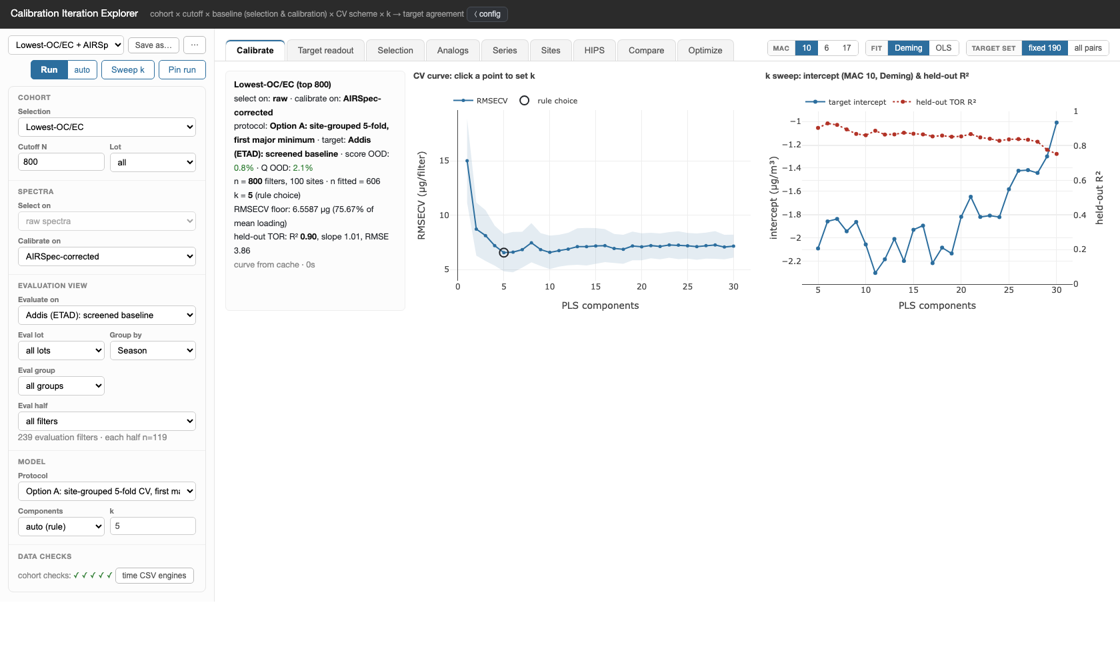

In [10]:
import subprocess
import sys

shot = PLOTS / "08_explorer_screenshot.png"
# Playwright's sync API cannot run inside the notebook kernel's asyncio loop, so the
# capture runs as a child process of the same interpreter.
CAPTURE = r'''
import sys, time
from playwright.sync_api import sync_playwright
base, out = sys.argv[1], sys.argv[2]
with sync_playwright() as p:
    browser = p.chromium.launch()
    page = browser.new_page(viewport={"width": 1680, "height": 1000})
    page.goto(base + "/", wait_until="networkidle")
    time.sleep(1.5)
    page.select_option("#preset", "b:5")
    time.sleep(0.5)
    page.click("#run")
    for _ in range(300):
        time.sleep(1)
        if (page.eval_on_selector_all("#p_curve .plotly", "e => e.length")
                and not page.get_attribute("#sweep", "disabled")):
            break
    page.click("#sweep")
    for _ in range(600):
        time.sleep(1)
        if page.eval_on_selector_all("#p_sweep .plotly", "e => e.length"):
            time.sleep(2)
            break
    page.screenshot(path=out, full_page=False)
    browser.close()
print("captured")
'''
try:
    proc = subprocess.run([sys.executable, "-c", CAPTURE, BASE, str(shot)],
                          capture_output=True, text=True, timeout=1200)
    if proc.returncode != 0 or not shot.exists():
        raise RuntimeError(proc.stderr.strip().splitlines()[-1] if proc.stderr.strip()
                           else f"exit {proc.returncode}")
    shot_note = ("live capture: preset 'Lowest-OC/EC + AIRSpec (800)', Option A, Deming, MAC 10, "
                 "fixed 190, after Run and Sweep k")
except Exception as exc:                                             # noqa: BLE001
    fallback = REPO / "deliverables/ftir_group_2026-08-27/figures/f_app_calibrate.png"
    shutil.copy(fallback, shot)
    shot_note = f"Playwright capture failed ({type(exc).__name__}: {exc}); copied {fallback}"
Image.open(shot).convert("RGB").save(shot)
MANIFEST.append((shot.name, shot_note))
print(shot_note)
display(Image.open(shot).resize((1120, 667)))

## 9. Backup images: PMF, implied MAC, aethalometer

What exists as a file is copied with its settings; the aethalometer-vs-FTIR figures
only exist embedded in executed notebooks, so those are extracted cell by cell and
named by the section they sit under. No standalone "aethalometer BC vs FTIR EC" or
"seasonal MAC" image exists in the repo, and this cell says so in the manifest.

In [11]:
import nbformat
import base64

BACKUP = PLOTS / "09_backup"
BACKUP.mkdir(exist_ok=True)
copies = [
    ("output/plots/crossplots/04_result_by_pmf_class_all.png", "09a_pmf_class_crossplot.png",
     "Same fitted model read out by PMF source class: lowest-OC/EC 450, baseline-corrected, "
     "Option A, k=9, MAC 10, Deming, all pairs (only the 102 evaluation filters with a PMF day)"),
    ("output/plots/ftir16/addis_implied_mac_distribution.png", "09b_addis_implied_mac.png",
     "ftir_16: distribution of implied MAC (Fabs / FTIR EC) at Addis; not seasonal"),
    ("output/plots/ftir31/improve_implied_mac_curve.png", "09c_improve_implied_mac_curve.png",
     "ftir_31 §3: implied MAC vs OC/EC across 151,843 IMPROVE filters (MAC 10 centred in the "
     "Addis-like OC/EC ≤ 2.27 subset)"),
    ("output/plots/ftir31/addis_spectra_by_season_corrected.png", "09d_addis_spectra_by_season.png",
     "ftir_31 §5: Addis baseline-corrected median spectra by season (Dry/Belg/Kiremt)"),
]
for src, dst, note in copies:
    src = Path(src)
    if src.exists():
        shutil.copy(src, BACKUP / dst)
        Image.open(BACKUP / dst).convert("RGB").save(BACKUP / dst)
        MANIFEST.append((f"09_backup/{dst}", note))
        print("copied", dst)
    else:
        print("missing", src)

embedded_sources = [
    ("ftir_28_ma350_brc_falsification.ipynb", "ftir28"),
    ("../ftir_hips_chem/HIPS_vs_Aethalometer_Optical_Comparison.ipynb", "hips_vs_aeth"),
]
for nb_path, tag in embedded_sources:
    nb_path = Path(nb_path)
    if not nb_path.exists():
        print("missing notebook", nb_path)
        continue
    nb = nbformat.read(nb_path, as_version=4)
    header, n = "", 0
    for cell in nb.cells:
        if cell.cell_type == "markdown":
            first = cell.source.strip().splitlines()[0] if cell.source.strip() else ""
            if first.startswith("#"):
                header = first.lstrip("# ").strip()
            continue
        for out in cell.get("outputs", []):
            png = out.get("data", {}).get("image/png")
            if not png:
                continue
            n += 1
            slug = "".join(ch if ch.isalnum() else "_" for ch in header)[:60].strip("_")
            dst = BACKUP / f"09e_{tag}_{n:02d}_{slug}.png"
            Image.open(io.BytesIO(base64.b64decode(png))).convert("RGB").save(dst)
            MANIFEST.append((f"09_backup/{dst.name}",
                             f"extracted from {nb_path.name}, section '{header}' (settings as "
                             "in that notebook; aethalometer/HIPS/FTIR comparison, not a "
                             "phase-3 calibration figure)"))
    print(f"{nb_path.name}: {n} embedded figures extracted")
MANIFEST.append(("09_backup/(note)",
                 "No standalone 'aethalometer BC vs FTIR EC' or 'seasonal MAC' image exists in the "
                 "repo; the closest are the extracted ftir_28 / HIPS_vs_Aethalometer figures and "
                 "the implied-MAC figures above."))

copied 09a_pmf_class_crossplot.png
copied 09b_addis_implied_mac.png
copied 09c_improve_implied_mac_curve.png


copied 09d_addis_spectra_by_season.png
ftir_28_ma350_brc_falsification.ipynb: 2 embedded figures extracted


HIPS_vs_Aethalometer_Optical_Comparison.ipynb: 10 embedded figures extracted


## 10. Permutation output CSV

The explorer's batch cache, flattened to one row per scored configuration on the Addis
target: cohort, cutoff (n), selection space, calibration spectra, protocol (rule),
training lot, evaluation view, k, whether k was the rule choice, OLS and Deming slope
and intercept at MAC 10 on the fixed 190 and on all pairs, R², RMSE, held-out TOR R².

In [12]:
batch_path = REPO / "calibration_explorer/cache/batch_results.jsonl"
rows = [json.loads(line) for line in batch_path.read_text().splitlines() if line.strip()]
batch = pd.DataFrame(rows)
for col in ("eval_group", "eval_split", "eval_lot", "lot", "selection_space"):
    if col in batch:
        batch[col] = batch[col].fillna("all" if col != "selection_space" else "raw")
addis = batch[batch["target"] == "addis"].copy()
addis["rule"] = addis["mode"].map({"site_heldout": "A site-grouped 5-fold FMM",
                                   "app": "B interleaved 10-fold within-5%",
                                   "app_fmm": "B2 interleaved 10-fold FMM"}).fillna(addis["mode"])
addis["k_is_rule_choice"] = addis["k"] == addis["auto_k"]
addis["n"] = addis["cutoff"].fillna(runs["network_raw"]["n_cohort"]).astype(int)
keep = ["cohort", "cohort_label", "n", "cutoff", "selection_space", "spectra", "mode", "rule",
        "lot", "eval_lot", "eval_group", "eval_split", "k", "auto_k", "k_is_rule_choice",
        "ols_slope", "ols_intercept", "deming_slope", "deming_intercept", "R2", "RMSE",
        "all_ols_slope", "all_ols_intercept", "all_deming_slope", "all_deming_intercept",
        "all_R2", "all_RMSE", "heldout_R2", "extrap_pct", "q_residual_pct", "negative_pct"]
keep = [c for c in keep if c in addis.columns]
perm = addis[keep].drop_duplicates()
perm_path = TABLES / "permutation_runs_addis.csv"
perm.to_csv(perm_path, index=False)
print(f"{len(batch):,} cached rows total, {len(perm):,} unique Addis rows -> {perm_path}")
print("slope/intercept columns are Deming/OLS at MAC 10 on the fixed 190; all_* = all pairs")
display(perm.groupby(["cohort", "spectra", "mode"]).size().unstack(fill_value=0))

82,934 cached rows total, 27,361 unique Addis rows -> output/tables/ftir51/permutation_runs_addis.csv
slope/intercept columns are Deming/OLS at MAC 10 on the fixed 190; all_* = all pairs


mode                app  app_fmm  site_heldout
cohort     spectra                            
analogs    airspec  412      390          2761
           deriv2   409      397          2506
           raw      408      386          2570
eth_shaped airspec  345      340          1841
           deriv2   361      363          2213
           raw      348      348          1900
ocec       airspec  211      221          2384
           deriv2   225      225          2447
           raw      221      228          2552
pool       airspec   22       23            31
           deriv2    23       20            32
           raw       22       16            26
smoke      airspec   15       14            21
           deriv2    16       14            21
           raw        8        4            21

## 11. OC/EC and OC/fAbs by site: SPARTAN placed in the IMPROVE ranking

Rebuilt from `research/spartan/follow_up_mass_and_ratio_plots.ipynb` (figs 03 and 08)
with two changes: one figure per ratio with the legend outside the axes, and SPARTAN
shown as **FTIR OC/EC only**. The earlier "thermal" stars came from the ChemSpec carbon
columns, which ftir_27 showed are the FTIR values re-published (EC_ftir bit-for-bit, OC
likewise), so they were never an independent thermal measurement; SPARTAN filters carry
FTIR, HIPS and UV-Vis, not thermal-optical carbon. IMPROVE OC and EC are thermal-optical
(TOR) from the FED export; sites need at least 50 valid filters.

In [13]:
IMPROVE_CACHE = REPO / "research/spartan/.cache/improve_chemistry_clean_cache.pkl"
SPARTAN_PKL = REPO / "research/ftir_hips_chem/Filter Data/unified_filter_dataset.pkl"
SITE_NAMES = {"CHTS": "Beijing", "ETAD": "Addis Ababa", "INDH": "Delhi", "USPA": "Pasadena/JPL"}
try:
    sys.path.insert(0, str(REPO / "research/ftir_hips_chem/scripts"))
    from config import SITES as _SITES
    SITE_COLORS = {site["code"]: site["color"] for site in _SITES.values()}
except Exception:                                                    # noqa: BLE001
    SITE_COLORS = {"ETAD": "#F39C12", "INDH": "#3498DB", "CHTS": "#E74C3C", "USPA": "#2ECC71"}
MIN_SITE_N = 50

imp = pd.read_pickle(IMPROVE_CACHE)
imp_valid = imp[(imp["ECf_Val"] > 0) & (imp["fAbs_Val"] > 0) & (imp["OCf_Val"] > 0)].copy()
imp_valid["OC_EC"] = imp_valid["OCf_Val"] / imp_valid["ECf_Val"]
imp_valid["OC_Fabs"] = imp_valid["OCf_Val"] / imp_valid["fAbs_Val"]

sp = pd.read_pickle(SPARTAN_PKL)
sp["SampleDate"] = pd.to_datetime(sp["SampleDate"], errors="coerce")
sp["base"] = sp["FilterId"].astype(str).str.replace(r"-\d+$", "", regex=True)


def param(name):
    d = sp.loc[sp["Parameter"].eq(name), ["Site", "base", "SampleDate", "Concentration"]]
    return d.rename(columns={"Concentration": name})


sp_pairs = (param("HIPS_Fabs").merge(param("EC_ftir"), on=["Site", "base", "SampleDate"])
            .merge(param("OC_ftir"), on=["Site", "base", "SampleDate"]))
sp_pairs = sp_pairs[(sp_pairs["HIPS_Fabs"] > 0) & (sp_pairs["EC_ftir"] > 0)
                    & (sp_pairs["OC_ftir"] > 0)].copy()
sp_pairs["OC_EC"] = sp_pairs["OC_ftir"] / sp_pairs["EC_ftir"]
sp_pairs["OC_Fabs"] = sp_pairs["OC_ftir"] / sp_pairs["HIPS_Fabs"]
print(f"IMPROVE valid OC/EC/fAbs rows: {len(imp_valid):,} over {imp_valid['SiteCode'].nunique()} sites; "
      f"SPARTAN same-filter FTIR+HIPS rows: {sp_pairs.groupby('Site').size().to_dict()}")


def site_ratio_table(df, site_col, ratio_col, min_n):
    g = df[[site_col, ratio_col]].replace([np.inf, -np.inf], np.nan).dropna().groupby(site_col)[ratio_col]
    t = g.agg(n="size", median="median", p25=lambda v: v.quantile(0.25), p75=lambda v: v.quantile(0.75))
    return t[t["n"] >= min_n].sort_values("median").reset_index()


def site_rank_figure(ratio_col, ylabel, xlabel, fname, fmt):
    imp_t = site_ratio_table(imp_valid, "SiteCode", ratio_col, MIN_SITE_N)
    sp_t = site_ratio_table(sp_pairs, "Site", ratio_col, 10)
    fig, ax = plt.subplots(figsize=(11, 5.4))
    x = np.arange(len(imp_t))
    ax.errorbar(x, imp_t["median"],
                yerr=[imp_t["median"] - imp_t["p25"], imp_t["p75"] - imp_t["median"]],
                fmt="o", ms=3, color="0.55", ecolor="0.8", elinewidth=0.7,
                label=f"IMPROVE sites (n={len(imp_t)}, median ± IQR; thermal-optical OC, EC)")
    for _, r in sp_t.iterrows():
        rank = int(np.searchsorted(imp_t["median"].values, r["median"]))
        ax.errorbar([rank], [r["median"]],
                    yerr=[[r["median"] - r["p25"]], [r["p75"] - r["median"]]],
                    fmt="*", ms=17, color=SITE_COLORS.get(r["Site"], "0.3"),
                    ecolor=SITE_COLORS.get(r["Site"], "0.3"), elinewidth=1.3, zorder=5,
                    label=f"{r['Site']} {SITE_NAMES.get(r['Site'], '')}: FTIR, "
                          f"{fmt.format(r['median'])} (n={int(r['n'])}, rank {rank + 1})")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(frameon=True, framealpha=0.95, edgecolor="#DDDAD2", fontsize=8.5, loc="upper left")
    fig.tight_layout()
    note = (f"IMPROVE: FED chemistry export, sites with ≥{MIN_SITE_N} filters having OC, EC and fAbs > 0, "
            "site median ± IQR of the per-filter ratio, OC and EC thermal-optical (TOR); SPARTAN: FTIR OC "
            "and EC with HIPS fAbs on the same filter (unified_filter_dataset.pkl), placed at the rank its "
            "median would take in the IMPROVE ordering (no thermal-optical carbon exists for SPARTAN; the "
            "ChemSpec carbon columns are FTIR re-published) · " +
            "; ".join(f"{r['Site']} {fmt.format(r['median'])}" for _, r in sp_t.iterrows()))
    save(fig, fname, note)
    return imp_t, sp_t


imp_ocec, sp_ocec = site_rank_figure("OC_EC", "OC / EC", "IMPROVE sites, ranked by median OC/EC",
                                     "11a_oc_ec_by_site.png", "{:.2f}")
imp_ocfabs, sp_ocfabs = site_rank_figure("OC_Fabs", "OC / fAbs  (µg m⁻³ per Mm⁻¹)",
                                         "IMPROVE sites, ranked by median OC/fAbs",
                                         "11b_oc_fabs_by_site.png", "{:.3f}")
pd.concat([sp_ocec.assign(ratio="OC/EC"), sp_ocfabs.assign(ratio="OC/fAbs")]).to_csv(
    TABLES / "spartan_site_ratios_ftir.csv", index=False)
display(pd.concat([sp_ocec.assign(ratio="OC/EC"), sp_ocfabs.assign(ratio="OC/fAbs")]).round(3))

IMPROVE valid OC/EC/fAbs rows: 378,322 over 214 sites; SPARTAN same-filter FTIR+HIPS rows: {'CHTS': 160, 'ETAD': 190, 'INDH': 61, 'USPA': 130}


saved output/plots/ftir51/11a_oc_ec_by_site.png


saved output/plots/ftir51/11b_oc_fabs_by_site.png


,Site,n,median,p25,p75,ratio
0,ETAD,190,1.343,1.263,1.425,OC/EC
1,INDH,61,2.132,1.863,2.337,OC/EC
2,CHTS,160,2.716,2.169,3.228,OC/EC
3,USPA,130,3.730,3.144,4.676,OC/EC
0,ETAD,190,0.127,0.104,0.168,OC/fAbs
1,INDH,61,0.233,0.183,0.278,OC/fAbs
2,CHTS,160,0.268,0.220,0.319,OC/fAbs
3,USPA,130,0.433,0.361,0.504,OC/fAbs


### 11c, 11d. The lowest-OC/EC 800 cohort against the Addis filters, per filter

The site-ranked plots above compare site medians; these use the same ranked format one
level down, with only the calibration cohort on the continuum: the lowest-OC/EC 800 calibration cohort (its own TOR OC/EC; OC and
fAbs for OC/fAbs joined from the FED export by site and date, ~730 of 800 match), and the Addis filters
(FTIR OC and EC with HIPS fAbs on the same filter). IMPROVE carbon is thermal-optical and
Addis carbon is FTIR, so the OC/EC panel compares methods as much as aerosols; the
OC/fAbs panel shares the optical denominator.

In [14]:
cohort = pd.read_csv("output/tables/ftir11/lowest_ocec_800_cohort.csv")
cohort["Date"] = pd.to_datetime(cohort["SampleDate"], format="%m/%d/%Y %I:%M:%S %p", errors="coerce")
cohort = cohort.merge(imp[["SiteCode", "Date", "fAbs_Val", "OCf_Val"]].drop_duplicates(["SiteCode", "Date"]),
                      left_on=["Site", "Date"], right_on=["SiteCode", "Date"], how="left")
cohort["OC_EC"] = cohort["OC_EC_ratio"]
# The cohort table's TOR_*_ugm3 columns are ng/m³ despite the name (local_db convention);
# use the FED export's OC (µg/m³) for the same site+date so the cohort and the network share
# one source for OC/fAbs.
cohort["OC_Fabs"] = np.where((cohort["fAbs_Val"] > 0) & (cohort["OCf_Val"] > 0),
                             cohort["OCf_Val"] / cohort["fAbs_Val"], np.nan)
addis = sp_pairs[sp_pairs["Site"] == "ETAD"]
print(f"cohort OC/fAbs available for {cohort['OC_Fabs'].notna().sum()} of 800 (FED join by site+date); "
      f"Addis filters {len(addis)}")

ETAD_COLOUR = SITE_COLORS.get("ETAD", AMBER)


def cohort_continuum(col, ylabel, xlabel, fname, fmt, log_y=False):
    """Same format as the site plots, one point per filter: the 800 lowest-OC/EC cohort
    filters ranked by their ratio form the continuum; each Addis filter sits at the rank
    its own ratio would take in that ordering."""
    v_c = np.asarray(cohort[col], float)
    base = np.sort(v_c[np.isfinite(v_c) & (v_c > 0)])
    v_a = np.asarray(addis[col], float)
    v_a = v_a[np.isfinite(v_a) & (v_a > 0)]
    ranks = np.searchsorted(base, v_a) + 1
    fig, ax = plt.subplots(figsize=(11, 5.4))
    ax.plot(np.arange(1, len(base) + 1), base, marker="o", ms=3.2, lw=0.8, color=PURPLE, alpha=0.8,
            label=f"Lowest-OC/EC 800 cohort, ranked (n={len(base)}; thermal-optical OC, EC; "
                  f"median {fmt.format(np.median(base))})")
    ax.scatter(ranks, v_a, s=60, marker="*", color=ETAD_COLOUR, alpha=0.85, edgecolor="none", zorder=5,
               label=f"Addis ETAD filters (FTIR OC, EC; HIPS fAbs): n={len(v_a)}, "
                     f"median {fmt.format(np.median(v_a))}, median rank {int(np.median(ranks))} of {len(base)}")
    ax.axhline(np.median(v_a), color=ETAD_COLOUR, lw=1.2, ls="--")
    if log_y:
        ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(frameon=True, framealpha=0.95, edgecolor="#DDDAD2", fontsize=8.5, loc="upper left")
    fig.tight_layout()
    rows = [{"ratio": col, "group": "Lowest-OC/EC 800 cohort", "n": len(base), "median": np.median(base),
             "p25": np.percentile(base, 25), "p75": np.percentile(base, 75), "median_rank": len(base) // 2},
            {"ratio": col, "group": "Addis ETAD filters", "n": len(v_a), "median": np.median(v_a),
             "p25": np.percentile(v_a, 25), "p75": np.percentile(v_a, 75), "median_rank": int(np.median(ranks)),
             "share_below_cohort_median": float((v_a < np.median(base)).mean())}]
    note = ("Per-filter continuum: the lowest-OC/EC 800 cohort ranked by the ratio (TOR OC/EC from the cohort "
            "table; OC and fAbs for OC/fAbs from the FED export by site+date, "
            + str(int(cohort["OC_Fabs"].notna().sum())) + " of 800), Addis ETAD filters (FTIR OC and EC, "
            "HIPS fAbs, same filter) placed at the rank their ratio takes in that ordering; dashed = Addis "
            f"median · cohort median {fmt.format(np.median(base))}, Addis median {fmt.format(np.median(v_a))} "
            f"at rank {int(np.median(ranks))} of {len(base)}; {100 * rows[1]['share_below_cohort_median']:.0f}% "
            "of Addis filters sit below the cohort median")
    save(fig, fname, note)
    return rows


cont_rows = cohort_continuum("OC_EC", "OC / EC", "lowest-OC/EC cohort filters, ranked by OC/EC",
                             "11c_cohort800_vs_addis_oc_ec.png", "{:.2f}")
cont_rows += cohort_continuum("OC_Fabs", "OC / fAbs  (µg m⁻³ per Mm⁻¹, log scale)",
                              "lowest-OC/EC cohort filters, ranked by OC/fAbs",
                              "11d_cohort800_vs_addis_oc_fabs.png", "{:.3f}", log_y=True)
cohort_stats = pd.DataFrame(cont_rows)
cohort_stats.to_csv(TABLES / "cohort_vs_addis_ratios.csv", index=False)
display(cohort_stats.round(3))

cohort OC/fAbs available for 734 of 800 (FED join by site+date); Addis filters 190


saved output/plots/ftir51/11c_cohort800_vs_addis_oc_ec.png


saved output/plots/ftir51/11d_cohort800_vs_addis_oc_fabs.png


,ratio,group,n,median,p25,p75,median_rank,share_below_cohort_median
0,OC_EC,Lowest-OC/EC 800 cohort,800,1.857,1.375,2.100,400,NaN
1,OC_EC,Addis ETAD filters,190,1.343,1.263,1.425,193,0.989
2,OC_Fabs,Lowest-OC/EC 800 cohort,734,0.198,0.136,0.276,367,NaN
3,OC_Fabs,Addis ETAD filters,190,0.127,0.104,0.168,175,0.937


## Manifest and packet

In [15]:
manifest_lines = ["# ftir_51 figure packet — settings per file", "",
                  f"Explorer commit {status['provenance']['git_commit']}"
                  f"{' (dirty)' if status['provenance']['git_dirty'] else ''}, "
                  f"exported {time.strftime('%Y-%m-%d %H:%M')}. Unless stated: Option A "
                  "(site-grouped 5-fold CV, first major minimum), Deming λ*=2.96, MAC 10, fixed 190 "
                  "Addis filters, training lot all, target Addis (ETAD) screened baseline.", ""]
for name, note in MANIFEST:
    manifest_lines.append(f"- **{name}**: {note}")
manifest_lines += ["", "Tables: " + ", ".join(sorted(p.name for p in TABLES.glob("*.csv")))]
(PLOTS / "MANIFEST.md").write_text("\n".join(manifest_lines))

zip_path = PLOTS / "ftir51_priority_figures.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in sorted(PLOTS.rglob("*.png")):
        zf.write(p, p.relative_to(PLOTS))
    zf.write(PLOTS / "MANIFEST.md", "MANIFEST.md")
    for p in sorted(TABLES.glob("*.csv")):
        zf.write(p, f"tables/{p.name}")
print(f"packet: {zip_path} ({zip_path.stat().st_size / 1e6:.1f} MB)")
display(Markdown("\n".join(manifest_lines)))

packet: output/plots/ftir51/ftir51_priority_figures.zip (9.6 MB)


# ftir_51 figure packet — settings per file

Explorer commit f48fda4d41fb68d0c9fdb4fa1f918c179d360b49 (dirty), exported 2026-09-01 14:11. Unless stated: Option A (site-grouped 5-fold CV, first major minimum), Deming λ*=2.96, MAC 10, fixed 190 Addis filters, training lot all, target Addis (ETAD) screened baseline.

- **01_addis_crossplots_before_after.png**: (a) IMPROVE-wide, raw spectra: Entire IMPROVE network (no selection) (n=13010) · calibrated on raw · Option A: site-grouped 5-fold CV, first major minimum · k=15 · MAC 10 · training lot all · eval Addis fixed 190 (n=190) · Deming 1.94x-4.82 · OLS 1.65x-3.44 · R² 0.75 · held-out TOR R² 0.70
    (b) IMPROVE-wide, baseline-corrected: Entire IMPROVE network (no selection) (n=13010) · calibrated on baseline-corrected (AIRSpec) · Option A: site-grouped 5-fold CV, first major minimum · k=7 · MAC 10 · training lot all · eval Addis fixed 190 (n=190) · Deming 0.47x-0.78 · OLS 0.46x-0.70 · R² 0.65 · held-out TOR R² 0.66
    (c) spectral analogs, selected on raw: Spectral analogs (top 500) (n=500) · selected on raw · calibrated on raw · Option A: site-grouped 5-fold CV, first major minimum · k=4 · MAC 10 · training lot all · eval Addis fixed 190 (n=190) · Deming 3.09x-9.32 · OLS 2.48x-6.35 · R² 0.75 · held-out TOR R² 0.37
    (d) analogs selected on baseline-corrected: Spectral analogs (top 500, corrected-space selection) (n=500) · selected on baseline-corrected (AIRSpec) · calibrated on raw · Option A: site-grouped 5-fold CV, first major minimum · k=15 · MAC 10 · training lot all · eval Addis fixed 190 (n=190) · Deming 1.94x-4.68 · OLS 1.63x-3.17 · R² 0.73 · held-out TOR R² 0.70
- **02a_component_sweep_intercept.png**: k in [3, 4, 6, 8, 10, 12, 15, 18, 21, 24, 30]; all seven variants under Option A: site-grouped 5-fold CV, first major minimum; intercept = Deming MAC 10 on fixed 190; held-out R² = site-disjoint IMPROVE TOR test; training lot all; hollow marker = rule-chosen (or pinned) k; raw calibrations dashed, baseline-corrected solid. Rows in output/tables/ftir51/component_sweep.csv
- **02b_component_sweep_heldout_r2.png**: k in [3, 4, 6, 8, 10, 12, 15, 18, 21, 24, 30]; all seven variants under Option A: site-grouped 5-fold CV, first major minimum; intercept = Deming MAC 10 on fixed 190; held-out R² = site-disjoint IMPROVE TOR test; training lot all; hollow marker = rule-chosen (or pinned) k; raw calibrations dashed, baseline-corrected solid. Rows in output/tables/ftir51/component_sweep.csv
- **03_seasonal_robustness.png**: Four calibrations, all dated Addis evaluation filters (all lots), Option A: site-grouped 5-fold CV, first major minimum, MAC 10 · network_raw: k=15, Kiremt/Dry=2.18 | analogs_selcorr: k=15, Kiremt/Dry=2.15 | ocec800_raw: k=6, Kiremt/Dry=2.03 | ocec800_corr: k=5, Kiremt/Dry=2.17
- **04_analog_rank_distributions.png**: Spectral-analog rank score (mean percentile of nearest-Addis score-space D² and VIP-weighted RMSE) over the whole pool; cutoff = top 500 · raw: n_total=13010, cutoff metric=0.0956, peak=0.7800, histogram clipped at p99=0.984 | airspec: n_total=13010, cutoff metric=0.1723, peak=0.3541, histogram clipped at p99=0.983
- **05_cv_protocol_comparison.png**: Same cohort under three protocols; A = site-grouped 5-fold CV + first major minimum (site-held-out), B = interleaved 10-fold + within-5% (the calibration app), B2 = interleaved 10-fold + first major minimum; MAC 10, fixed 190, lot all. Table in output/tables/ftir51/cv_protocol_comparison.csv
- **06_lot_248_vs_251.png**: lot 248 raw: Lowest-OC/EC (top 800) · lot 248 (n=173) · calibrated on raw · Option A: site-grouped 5-fold CV, first major minimum · k=5 · MAC 10 · training lot 248 · eval Addis fixed 190 (n=190) · Deming 1.84x-4.34 · OLS 1.60x-3.17 · R² 0.77 · held-out TOR R² 0.94
    lot 251 raw: Lowest-OC/EC (top 800) · lot 251 (n=619) · calibrated on raw · Option A: site-grouped 5-fold CV, first major minimum · k=7 · MAC 10 · training lot 251 · eval Addis fixed 190 (n=190) · Deming 1.95x-4.74 · OLS 1.67x-3.37 · R² 0.76 · held-out TOR R² 0.95
    lot 248 airspec: Lowest-OC/EC (top 800) · lot 248 (n=173) · calibrated on baseline-corrected (AIRSpec) · Option A: site-grouped 5-fold CV, first major minimum · k=5 · MAC 10 · training lot 248 · eval Addis fixed 190 (n=190) · Deming 0.80x-1.50 · OLS 0.73x-1.18 · R² 0.65 · held-out TOR R² 0.96
    lot 251 airspec: Lowest-OC/EC (top 800) · lot 251 (n=619) · calibrated on baseline-corrected (AIRSpec) · Option A: site-grouped 5-fold CV, first major minimum · k=4 · MAC 10 · training lot 251 · eval Addis fixed 190 (n=190) · Deming 0.92x-2.08 · OLS 0.81x-1.56 · R² 0.60 · held-out TOR R² 0.93
- **07_plausibility_markers.png**: Per-variant plausibility on all 239 Addis evaluation filters (all lots), Option A: site-grouped 5-fold CV, first major minimum, MAC 10, lot all; trend = OLS slope of prediction vs sampling date. Table in output/tables/ftir51/plausibility_markers.csv
- **08_explorer_screenshot.png**: live capture: preset 'Lowest-OC/EC + AIRSpec (800)', Option A, Deming, MAC 10, fixed 190, after Run and Sweep k
- **09_backup/09a_pmf_class_crossplot.png**: Same fitted model read out by PMF source class: lowest-OC/EC 450, baseline-corrected, Option A, k=9, MAC 10, Deming, all pairs (only the 102 evaluation filters with a PMF day)
- **09_backup/09b_addis_implied_mac.png**: ftir_16: distribution of implied MAC (Fabs / FTIR EC) at Addis; not seasonal
- **09_backup/09c_improve_implied_mac_curve.png**: ftir_31 §3: implied MAC vs OC/EC across 151,843 IMPROVE filters (MAC 10 centred in the Addis-like OC/EC ≤ 2.27 subset)
- **09_backup/09d_addis_spectra_by_season.png**: ftir_31 §5: Addis baseline-corrected median spectra by season (Dry/Belg/Kiremt)
- **09_backup/09e_ftir28_01_Figure_1___the_measured_AAE__and_the_AAE_the_intercept_would.png**: extracted from ftir_28_ma350_brc_falsification.ipynb, section 'Figure 1 — the measured AAE, and the AAE the intercept would need' (settings as in that notebook; aethalometer/HIPS/FTIR comparison, not a phase-3 calibration figure)
- **09_backup/09e_ftir28_02_Figure_2___the_three_suspect_channels_against_IR.png**: extracted from ftir_28_ma350_brc_falsification.ipynb, section 'Figure 2 — the three suspect channels against IR' (settings as in that notebook; aethalometer/HIPS/FTIR comparison, not a phase-3 calibration figure)
- **09_backup/09e_hips_vs_aeth_01_6__Compare_HIPS_vs_ATN__Raw_Optical.png**: extracted from HIPS_vs_Aethalometer_Optical_Comparison.ipynb, section '6. Compare HIPS vs ATN (Raw Optical)' (settings as in that notebook; aethalometer/HIPS/FTIR comparison, not a phase-3 calibration figure)
- **09_backup/09e_hips_vs_aeth_02_6__Compare_HIPS_vs_ATN__Raw_Optical.png**: extracted from HIPS_vs_Aethalometer_Optical_Comparison.ipynb, section '6. Compare HIPS vs ATN (Raw Optical)' (settings as in that notebook; aethalometer/HIPS/FTIR comparison, not a phase-3 calibration figure)
- **09_backup/09e_hips_vs_aeth_03_6__Compare_HIPS_vs_ATN__Raw_Optical.png**: extracted from HIPS_vs_Aethalometer_Optical_Comparison.ipynb, section '6. Compare HIPS vs ATN (Raw Optical)' (settings as in that notebook; aethalometer/HIPS/FTIR comparison, not a phase-3 calibration figure)
- **09_backup/09e_hips_vs_aeth_04_6__Compare_HIPS_vs_ATN__Raw_Optical.png**: extracted from HIPS_vs_Aethalometer_Optical_Comparison.ipynb, section '6. Compare HIPS vs ATN (Raw Optical)' (settings as in that notebook; aethalometer/HIPS/FTIR comparison, not a phase-3 calibration figure)
- **09_backup/09e_hips_vs_aeth_05_7__Compare_HIPS_vs_BCc__Processed.png**: extracted from HIPS_vs_Aethalometer_Optical_Comparison.ipynb, section '7. Compare HIPS vs BCc (Processed)' (settings as in that notebook; aethalometer/HIPS/FTIR comparison, not a phase-3 calibration figure)
- **09_backup/09e_hips_vs_aeth_06_7__Compare_HIPS_vs_BCc__Processed.png**: extracted from HIPS_vs_Aethalometer_Optical_Comparison.ipynb, section '7. Compare HIPS vs BCc (Processed)' (settings as in that notebook; aethalometer/HIPS/FTIR comparison, not a phase-3 calibration figure)
- **09_backup/09e_hips_vs_aeth_07_7__Compare_HIPS_vs_BCc__Processed.png**: extracted from HIPS_vs_Aethalometer_Optical_Comparison.ipynb, section '7. Compare HIPS vs BCc (Processed)' (settings as in that notebook; aethalometer/HIPS/FTIR comparison, not a phase-3 calibration figure)
- **09_backup/09e_hips_vs_aeth_08_7__Compare_HIPS_vs_BCc__Processed.png**: extracted from HIPS_vs_Aethalometer_Optical_Comparison.ipynb, section '7. Compare HIPS vs BCc (Processed)' (settings as in that notebook; aethalometer/HIPS/FTIR comparison, not a phase-3 calibration figure)
- **09_backup/09e_hips_vs_aeth_09_8__Direct_Comparison__ATN_vs_BCc_Correlations_with_HIPS.png**: extracted from HIPS_vs_Aethalometer_Optical_Comparison.ipynb, section '8. Direct Comparison: ATN vs BCc Correlations with HIPS' (settings as in that notebook; aethalometer/HIPS/FTIR comparison, not a phase-3 calibration figure)
- **09_backup/09e_hips_vs_aeth_10_9__Wavelength_Specific_Analysis.png**: extracted from HIPS_vs_Aethalometer_Optical_Comparison.ipynb, section '9. Wavelength-Specific Analysis' (settings as in that notebook; aethalometer/HIPS/FTIR comparison, not a phase-3 calibration figure)
- **09_backup/(note)**: No standalone 'aethalometer BC vs FTIR EC' or 'seasonal MAC' image exists in the repo; the closest are the extracted ftir_28 / HIPS_vs_Aethalometer figures and the implied-MAC figures above.
- **11a_oc_ec_by_site.png**: IMPROVE: FED chemistry export, sites with ≥50 filters having OC, EC and fAbs > 0, site median ± IQR of the per-filter ratio, OC and EC thermal-optical (TOR); SPARTAN: FTIR OC and EC with HIPS fAbs on the same filter (unified_filter_dataset.pkl), placed at the rank its median would take in the IMPROVE ordering (no thermal-optical carbon exists for SPARTAN; the ChemSpec carbon columns are FTIR re-published) · ETAD 1.34; INDH 2.13; CHTS 2.72; USPA 3.73
- **11b_oc_fabs_by_site.png**: IMPROVE: FED chemistry export, sites with ≥50 filters having OC, EC and fAbs > 0, site median ± IQR of the per-filter ratio, OC and EC thermal-optical (TOR); SPARTAN: FTIR OC and EC with HIPS fAbs on the same filter (unified_filter_dataset.pkl), placed at the rank its median would take in the IMPROVE ordering (no thermal-optical carbon exists for SPARTAN; the ChemSpec carbon columns are FTIR re-published) · ETAD 0.127; INDH 0.233; CHTS 0.268; USPA 0.433
- **11c_cohort800_vs_addis_oc_ec.png**: Per-filter continuum: the lowest-OC/EC 800 cohort ranked by the ratio (TOR OC/EC from the cohort table; OC and fAbs for OC/fAbs from the FED export by site+date, 734 of 800), Addis ETAD filters (FTIR OC and EC, HIPS fAbs, same filter) placed at the rank their ratio takes in that ordering; dashed = Addis median · cohort median 1.86, Addis median 1.34 at rank 193 of 800; 99% of Addis filters sit below the cohort median
- **11d_cohort800_vs_addis_oc_fabs.png**: Per-filter continuum: the lowest-OC/EC 800 cohort ranked by the ratio (TOR OC/EC from the cohort table; OC and fAbs for OC/fAbs from the FED export by site+date, 734 of 800), Addis ETAD filters (FTIR OC and EC, HIPS fAbs, same filter) placed at the rank their ratio takes in that ordering; dashed = Addis median · cohort median 0.198, Addis median 0.127 at rank 175 of 734; 94% of Addis filters sit below the cohort median

Tables: cohort_vs_addis_ratios.csv, component_sweep.csv, cv_protocol_comparison.csv, permutation_runs_addis.csv, plausibility_markers.csv, seasonal_medians.csv, spartan_site_ratios_ftir.csv, variant_summary.csv

## Takeaways

- The packet is a pure export: every number is served by the explorer's shared
  implementation, so re-running this notebook against a live explorer regenerates all
  ten items and the manifest.
- The four-panel crossplot carries the intercept story on one image; the settings
  line under each panel is what the recipient asked for (variant, k, MAC, lot).
- The seasonal figure and the plausibility table use all 239 evaluation filters (all
  lots), while the crossplot and sweep numbers are fixed-190; the manifest names the
  evaluation set on every line so the two are never mixed.
- Items 9 (aethalometer / seasonal MAC) have no standalone image in the repo; the
  closest existing figures are copied or extracted, and the manifest says so.